# Model Compare · qwen2.5vl vs qwen3.5
Run both models on the same photo with the same structured prompt, then compare side-by-side.

## Config & Imports

In [ ]:
from dotenv import load_dotenv
load_dotenv(override=True)

# ── config ────────────────────────────────────────────────────
PROCESS_PHOTO = "All"   # filename (e.g. "Kinan.Sweidan-22.JPG") or "All" for every photo
MODEL_1 = "qwen2.5vl:latest"            # vision model
MODEL_2 = "qwen3.5:9b"                  # vision + text model — thinking disabled

# ── imports ───────────────────────────────────────────────────
from pathlib import Path
from PIL import Image
import base64, urllib.request, json, matplotlib.pyplot as plt, time
from IPython.display import display as ipy_display, HTML

RAW_DIR = Path("./data/raw")
photos = (
    sorted(p for ext in ("*.jpg", "*.JPG") for p in RAW_DIR.glob(ext))
    if PROCESS_PHOTO == "All"
    else [RAW_DIR / PROCESS_PHOTO]
)

# ── helpers ───────────────────────────────────────────────────
def ollama(prompt, image_b64=None, model=MODEL_1, think=None):
    """Call Ollama /api/generate. Passes image if provided, disables thinking if think=False."""
    payload = {"model": model, "prompt": prompt, "stream": False}
    if image_b64:
        payload["images"] = [image_b64]
    if think is not None:
        payload["think"] = think
    req = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
    )
    with urllib.request.urlopen(req, timeout=300) as r:
        return json.loads(r.read())["response"]

results = {}  # shared state across cells
print(f"Photos to process: {[p.name for p in photos]}")

## Prompt

In [2]:
ANALYSIS_PROMPT = """You are analyzing a black and white street photograph by Chicago photographer Kinan Sweidan.

Describe each field below. Be specific and concise.

subject: [primary subject, position, action — 1-2 sentences]
composition: [framing, rule of thirds, leading lines, negative space — 1-2 sentences]
lighting: [direction, quality, contrast, shadow detail — 1-2 sentences]
mood: [emotional tone, atmosphere — 1 sentence]
technical: [only include observable technical details — motion blur, grain, 
lens distortion. Omit any attribute you cannot directly observe. 1 sentence 
or none-observable if nothing is clearly visible.]
style_notes: [distinctive visual choices specific to street or portrait photography — 1 sentence]

Respond with only the key-value pairs above. No reasoning. No commentary. Nothing else."""

print(ANALYSIS_PROMPT)

You are analyzing a black and white street photograph by Chicago photographer Kinan Sweidan.

Describe each field below. Be specific and concise.

subject: [primary subject, position, action — 1-2 sentences]
composition: [framing, rule of thirds, leading lines, negative space — 1-2 sentences]
lighting: [direction, quality, contrast, shadow detail — 1-2 sentences]
mood: [emotional tone, atmosphere — 1 sentence]
technical: [only include observable technical details — motion blur, grain, 
lens distortion. Omit any attribute you cannot directly observe. 1 sentence 
or none-observable if nothing is clearly visible.]
style_notes: [distinctive visual choices specific to street or portrait photography — 1 sentence]

Respond with only the key-value pairs above. No reasoning. No commentary. Nothing else.


## Model 1 · qwen2.5vl (Vision)

In [3]:
for path in photos:
    with open(path, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode()

    t0 = time.time()
    m1_out = ollama(ANALYSIS_PROMPT, image_b64=img_b64, model=MODEL_1, think=False)
    t1 = time.time()

    results[path] = {"path": path, "img_b64": img_b64, "m1": m1_out, "t1": t1 - t0}
    print(f"✓ {path.name}  ({t1-t0:.1f}s)  [{MODEL_1}]\n\n{m1_out}\n")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/None'

## Model 2 · qwen3.5:9b (Vision, thinking off)

In [5]:
for path, r in results.items():
    t0 = time.time()
    m2_out = ollama(ANALYSIS_PROMPT, image_b64=r["img_b64"], model=MODEL_2, think=False)
    t2 = time.time()

    r["m2"] = m2_out
    r["t2"] = t2 - t0
    print(f"✓ {path.name}  ({t2-t0:.1f}s)  [{MODEL_2}]\n\n{m2_out}\n")

✓ Kinan.Sweidan-5.JPG  (24.6s)  [qwen3.5:9b]

subject: A lone figure walks away from the viewer down a narrow, sun-drenched urban street, positioned center-right and silhouetted against bright daylight at the vanishing point.

composition: Framed tightly between tall buildings, the sidewalk acts as a strong leading line toward the light; negative space dominates the left and right edges, emphasizing isolation and depth.

lighting: Hard, direct sunlight from the background creates high contrast with deep shadows in the foreground and midground; shadow detail is minimal, mostly limited to subtle textures on pavement and building facades.

mood: Melancholic and introspective, evoking solitude and the quiet drama of everyday city life under stark light.

technical: No motion blur or lens distortion is observable; fine grain suggests film capture, with crisp edges in lit areas and soft transitions into shadow.

style_notes: Utilizes extreme contrast and silhouette to transform an ordinary s

## Results · Side-by-Side

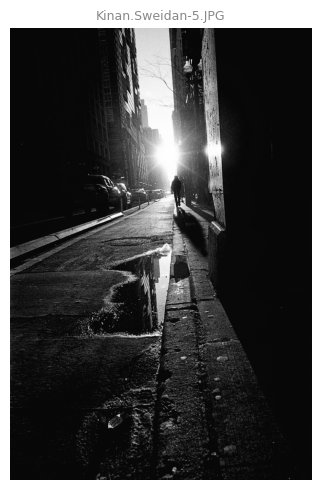

In [6]:
for path, r in results.items():
    fig, ax = plt.subplots(figsize=(4, 5))
    ax.imshow(Image.open(path))
    ax.axis("off")
    ax.set_title(path.name, fontsize=9, color="#888")
    plt.tight_layout()
    plt.show()

    t1 = r.get("t1", 0)
    t2 = r.get("t2", 0)

    ipy_display(HTML(f"""
    <div style="display:grid; grid-template-columns:1fr 1fr; gap:24px; font-family:monospace; font-size:12px; max-width:1200px; margin-top:8px">
      <div>
        <div style="color:#888; font-size:10px; margin-bottom:6px; border-bottom:1px solid #eee; padding-bottom:4px">
          MODEL 1 &nbsp;&middot;&nbsp; {MODEL_1} &nbsp;&middot;&nbsp; {t1:.1f}s
        </div>
        <div style="white-space:pre-wrap; line-height:1.8">{r.get('m1', '— run Model 1 cell first')}</div>
      </div>
      <div>
        <div style="color:#888; font-size:10px; margin-bottom:6px; border-bottom:1px solid #eee; padding-bottom:4px">
          MODEL 2 &nbsp;&middot;&nbsp; {MODEL_2} &nbsp;&middot;&nbsp; {t2:.1f}s &nbsp;&middot;&nbsp; thinking: off
        </div>
        <div style="white-space:pre-wrap; line-height:1.8">{r.get('m2', '— run Model 2 cell first')}</div>
      </div>
    </div>
    <div style="color:#aaa; font-size:10px; margin-top:10px">
      Total: {t1+t2:.1f}s &nbsp;|&nbsp; {MODEL_1}: {t1:.1f}s &nbsp;|&nbsp; {MODEL_2}: {t2:.1f}s
    </div>
    <hr style="margin:20px 0; border:none; border-top:1px solid #eee">
    """))